In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
import numpy as np
import os
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule
from src.utils import inspection
from src.models import ensembled_model
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

/home/jl_fs/workspace/projects/crowd_counting/venv/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
inspection.inspect_model('convnext_base')

In [2]:
model, params = MLFlowRegistry().load_model('models:/crowd_counting/75')

2026/08/20 19:58:20 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - matplotlib (current: 3.11.0, required: matplotlib==3.10.9)
 - torchlens (current: 2.34.1, required: torchlens==2.17.0)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
/home/jl_fs/workspace/projects/crowd_counting/venv/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
type(model)

In [5]:
params

BaseParams(image_size=None, crop_size=384, label_scaler=1000, aug_factor=None, num_ops=None, backbone='tu-convnext_base', model_class='MAnet', backbone_weights='imagenet', decoder_attention_type=None, trainable_backbone=False, neck_out_channels=None, decoder_out_channels=128, dropout=None, batch_size=16, val_batch_size=1, lr=0.00065, l2_reg=0.0001, lr_schedule='clipped_exp', ssim_weight=0.3, mask_loss_weight=1, huber_delta=5, mask_loss_alpha=0.815, mask_loss_gamma=3.17, k_threshold=None, seg_threshold=None, gt_mask_threshold=0, monitor_metric='val_nae', loss_function='mask_mse_ssim', grad_accumulation=1, grad_clip=None, scheduler_kwargs={'decay_rate': 0.96, 'min_lr_pct': 0.01}, suggested_params=False, epochs=70, check_val_every_n_epoch=1, padding_multiple=32, dataset='part_A', train_size=268, unfrozen_blocks=None, optimizer_config={}, extra={})

In [3]:
# import numpy as np
# dummy_input = np.random.randint(0, 256, size=(2, 704, 1056, 3), dtype=np.uint8)
model.predict(torch.randn(2, 3, 704, 1056))

(tensor([0.0008, 0.0007]),
 tensor([[[6.8828e-05, 0.0000e+00, 0.0000e+00,  ..., 1.9380e-04,
           2.0786e-04, 1.3311e-04],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 5.1757e-05],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [2.6344e-06, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [7.1187e-05, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]],
 
         [[1.1214e-04, 1.1437e-05, 0.0000e+00,  ..., 1.4306e-04,
           1.6336e-04, 1.1600e-04],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 5.9158e-05],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 0.0000e+

In [3]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage=None)

2261 images found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/train/images
2261 gt files found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/train/ground-truth-npy
Preloading 2261 samples to RAM. Watch your memory usage!


100%|██████████| 2261/2261 [00:50<00:00, 44.72it/s]


/home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/valid found. Loading validation set from folder.
497 images found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/valid/images
497 gt files found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/valid/ground-truth-npy
Preloading 497 samples to RAM. Watch your memory usage!


100%|██████████| 497/497 [00:09<00:00, 50.64it/s]


Pre-transforming 497 validation samples directly into VRAM (cuda)...


100%|██████████| 497/497 [00:05<00:00, 86.31it/s]

1600 images found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/test/images
1600 gt files found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/test/ground-truth-npy


In [4]:
model.evaluate(datamodule.val_dataloader())

{'mae': 67.99275970458984,
 'mbe': 6.061066627502441,
 'nae': 0.34303557872772217,
 'rmse': 231.5651092529297,
 'mask_dice': 0.5847793221473694,
 'mask_iou': 0.41320711374282837}

In [6]:
datamodule.val_dataloader().batch_size

1

In [ ]:
"""{'mae': 105.06348419189453,
 'mbe': -6.24075174331665,
 'nae': 0.8911219239234924,
 'rmse': 340.9920959472656,
 'mask_dice': 0.491184800863266,
 'mask_iou': 0.3255434036254883}"""

In [4]:
from src.models.ensembled_model import EnsembledCrowdCounter
versions = ['52', '55', '56', '57']
sub_models = [mlflow.pyfunc.load_model(f'models:/crowd_counting/{version}') for version in versions]
model = EnsembledCrowdCounter(sub_models)
# model = mlflow.pyfunc.load_model('models:/crowd_counting/53')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [5]:
model.evaluate(datamodule.ensemble_test_dataloader())

{'MAE': 70.36506652832031,
 'NAE': 0.18059852719306946,
 'RMSE': 115.29673767089844}

In [27]:
sample, target, count = helpers.get_sample_from_dm(datamodule, index=11)
sample.shape

torch.Size([1, 3, 608, 928])

In [ ]:
from torchvision.transforms import v2
from PIL import Image


from src.data import transform_sample
original_image = Image.open('/teamspace/studios/this_studio/workspace/crowd_counting/testing_images/input/0580.jpg').convert('RGB')
image = transform_sample.preprocess(original_image, params)
# image = np.array([original_image])

: 

In [6]:
result  = model.predict(image)
result = (float(result[0][0]), result[1])
result

(2793.645263671875,
 tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 2.5133e-05],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [3.3211e-05, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]]]))

In [8]:
result = (result[0]['count'], result[0]['density_map'])

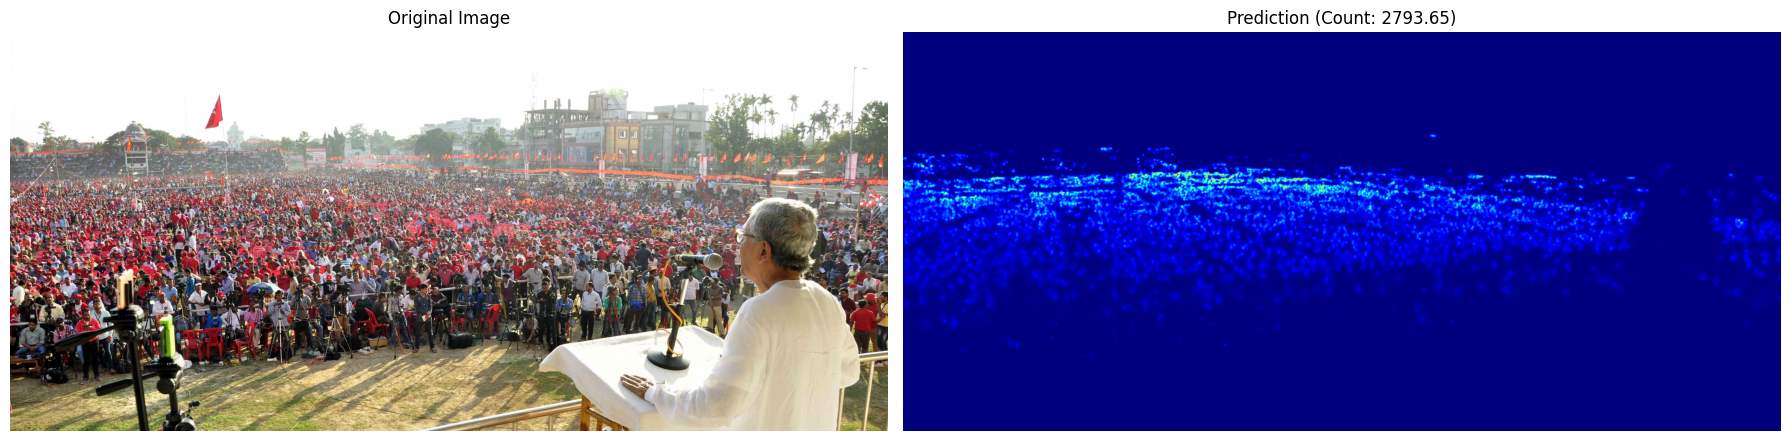

In [7]:
vis.visualize_sample(original_image, pred=result, cmap='jet')

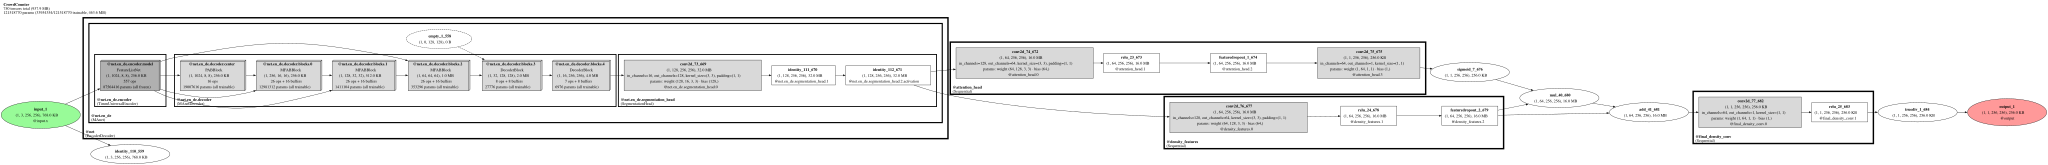

In [4]:
from torchlens.options import VisualizationOptions
vis.visualize_model_graph(model.model, sample=torch.randn(1, 3, 256, 256), options=VisualizationOptions(view='rolled', direction='leftright', depth=4, file_format='png'))